In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



df = pd.read_csv('/content/House Price Prediction Dataset.csv')

# Drop non-predictive ID column
df_model = df.drop(columns=['Id'])

# Add engineered features (Age_years, LocationScore, Size_sqft) to df_model
# Assuming age_years, location_score, size_sqft numpy arrays are already in the kernel state
df_model['Age_years'] = age_years
df_model['LocationScore'] = location_score
df_model['Size_sqft'] = size_sqft


In [49]:
# 2. Encode Categorical Features
df_encoded = pd.get_dummies(df_model, columns=['Location', 'Condition', 'Garage'], drop_first=True)


In [50]:

# 3. Train-Test Split
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']


In [37]:
from sklearn.linear_model import LinearRegression

# 4. Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
# 5. Predictions & Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}\n")


--- Model Performance Metrics ---
R² Score: -0.0067
Mean Absolute Error (MAE): $243,241.98
Root Mean Squared Error (RMSE): $279,859.73



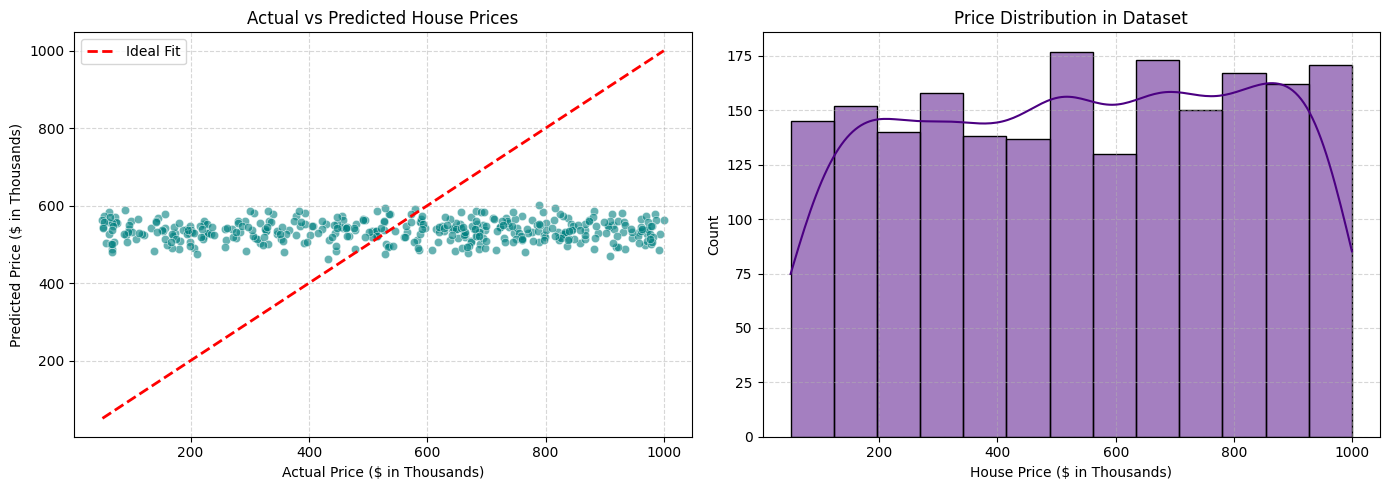

In [47]:
# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted Prices
sns.scatterplot(x=y_test / 1000, y=y_pred / 1000, alpha=0.6, ax=axes[0], color='teal')
axes[0].plot([y_test.min()/1000, y_test.max()/1000], [y_test.min()/1000, y_test.max()/1000], 'r--', lw=2, label='Ideal Fit')
axes[0].set_title('Actual vs Predicted House Prices')
axes[0].set_xlabel('Actual Price ($ in Thousands)')
axes[0].set_ylabel('Predicted Price ($ in Thousands)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Price Distribution in Dataset
sns.histplot(df['Price'] / 1000, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('Price Distribution in Dataset')
axes[1].set_xlabel('House Price ($ in Thousands)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [48]:
# 7. Function to Predict Price for a Custom Property
def predict_custom_house(area, bedrooms, bathrooms, floors, year_built, location, condition, garage):
    single_row = pd.DataFrame([{
        'Area': area,
        'Bedrooms': bedrooms,
        'Bathrooms': bathrooms,
        'Floors': floors,
        'YearBuilt': year_built,
        'Location': location,
        'Condition': condition,
        'Garage': garage
    }])

    # Align encoded columns with training features
    single_encoded = pd.get_dummies(single_row, columns=['Location', 'Condition', 'Garage'])
    single_encoded = single_encoded.reindex(columns=X.columns, fill_value=0)

    predicted_val = model.predict(single_encoded)[0]
    return predicted_val

# Example Prediction
sample_price = predict_custom_house(
    area=2500,
    bedrooms=3,
    bathrooms=2,
    floors=2,
    year_built=2010,
    location='Suburban',
    condition='Good',
    garage='Yes'
)
print(f"Estimated Price for Sample House: ${sample_price:,.2f}")

Estimated Price for Sample House: $542,791.36
